In [6]:
import numpy as np
import cv2
from PIL import Image
import torch
from torchvision import transforms as tv

from mnist_synthetic.utils.rotation import Rotation

from mnist_synthetic.torch.datasets.mnist_synthetic_dataset_rotated import (
    MNISTSyntheticRotate,
    MNISTSyntheticRotated
)

# Visualize

Generate digits with different ways (rotate position and augments)

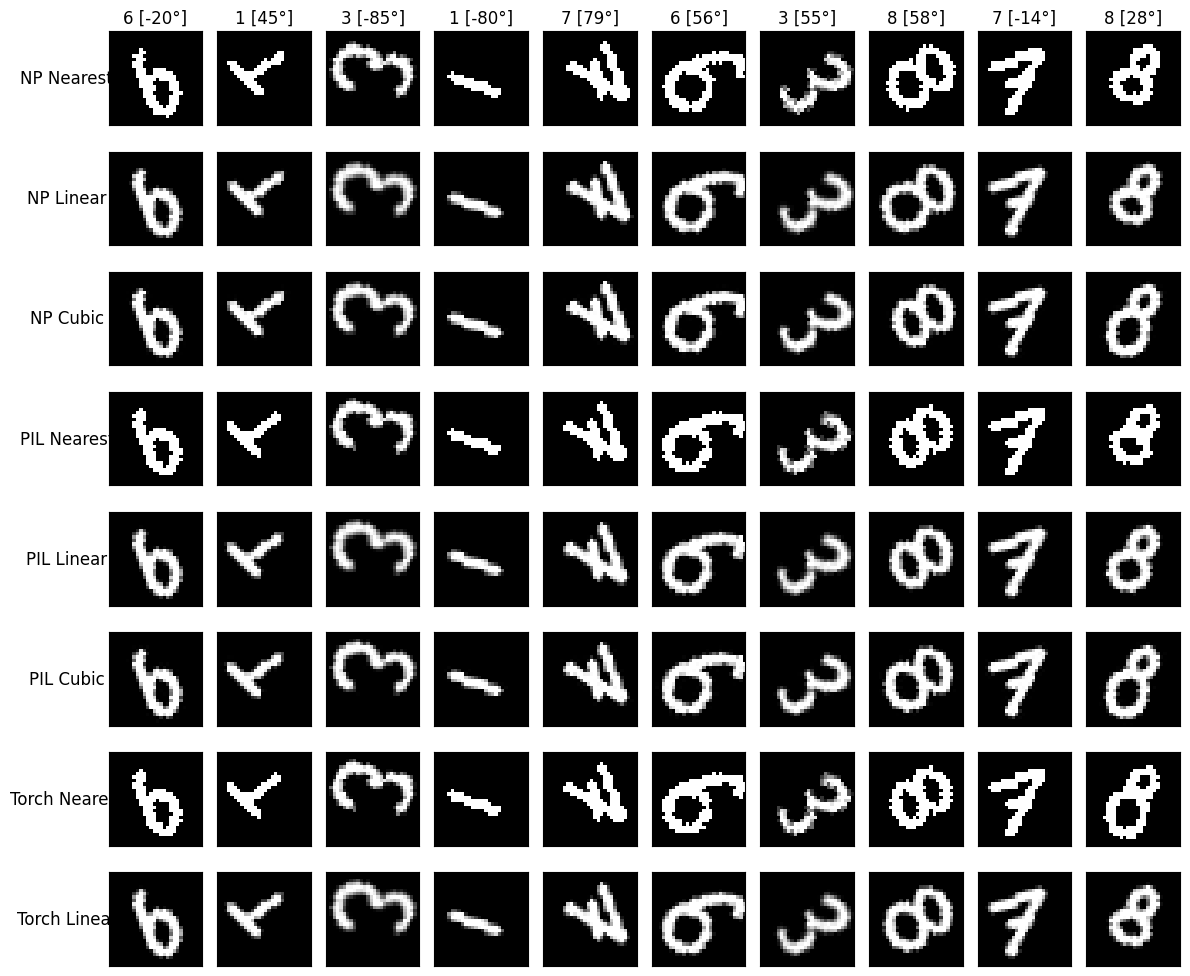

In [31]:
from matplotlib import pyplot as plt

ANGLE = 90
SEED = 12

rot_np = {
    'NE': Rotation(max_angle=ANGLE, interpolation=cv2.INTER_NEAREST, seed=SEED),
    'LN': Rotation(max_angle=ANGLE, interpolation=cv2.INTER_LINEAR, seed=SEED),
    'CU': Rotation(max_angle=ANGLE, interpolation=cv2.INTER_CUBIC, seed=SEED)
}
rot_pill = {
    'NE': Rotation(max_angle=ANGLE, interpolation=Image.Resampling.NEAREST, seed=SEED),
    'LN': Rotation(max_angle=ANGLE, interpolation=Image.Resampling.BILINEAR, seed=SEED),
    'CU': Rotation(max_angle=ANGLE, interpolation=Image.Resampling.BICUBIC, seed=SEED),
}
rot_torch = {
    'NE': Rotation(max_angle=ANGLE, interpolation=tv.InterpolationMode.NEAREST, seed=SEED),
    'LN': Rotation(max_angle=ANGLE, interpolation=tv.InterpolationMode.BILINEAR, seed=SEED),
}

transforms = tv.Compose([
    tv.ToTensor(),
])

N = 10
datasets = [
    ('NP Nearest', MNISTSyntheticRotated(size=N, rotate_before_np=rot_np['NE'], seed=SEED)),
    ('NP Linear', MNISTSyntheticRotated(size=N, rotate_before_np=rot_np['LN'], seed=SEED), ),
    ('NP Cubic', MNISTSyntheticRotated(size=N, rotate_before_np=rot_np['CU'], seed=SEED), ),
    ('PIL Nearest', MNISTSyntheticRotated(size=N, rotate_before_pill=rot_pill['NE'], seed=SEED), ),
    ('PIL Linear', MNISTSyntheticRotated(size=N, rotate_before_pill=rot_pill['LN'], seed=SEED), ),
    ('PIL Cubic', MNISTSyntheticRotated(size=N, rotate_before_pill=rot_pill['CU'], seed=SEED), ),
    ('Torch Nearest', MNISTSyntheticRotated(size=N, rotate_after=rot_torch['NE'], transform=tv.ToTensor(), seed=SEED), ),
    ('Torch Linear', MNISTSyntheticRotated(size=N, rotate_after=rot_torch['LN'], transform=tv.ToTensor(), seed=SEED), ),
]

fig, axes = plt.subplots(len(datasets), N, figsize=[12, 10])
for i, (name, ds) in enumerate(datasets):
    for j in range(N):
        ax = axes[i][j]

        img, label, angle = ds[j]
        if isinstance(img, torch.Tensor):
            img = img[0]

        ax.imshow(img, cmap='gray')
        ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
        if i == 0:
            ax.set_title(f'{label} [{angle}°]')

    axes[i, 0].set_ylabel(name, rotation=0, size=12, labelpad=30, va="center")

fig.tight_layout()